# Learning Curves, Overfitting & Underfitting

This notebook answers:

- Why does my model perform this way?
- Is my model too simple or too complex?
- Do I need more data or better tuning?

Goal:

Understand model behavior, not just results.

In [3]:
# DATA GENERATION

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification

# generate dataset
X, y = make_classification(
    n_samples=300,
    n_features=10,
    flip_y=0.1,   # 10% labels randomly wrong
    random_state=42
)

print("Shape:", X.shape)

Shape: (300, 10)


In [4]:
# SIMPLE SETUP
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

## What is a Learning Curve?

A learning curve shows:

    model performance vs training data size

### Two lines:

Training score:
    performance on data model saw

Validation score:
    performance on unseen data


### Key Insight

Learning curves show:

    how model improves with more data

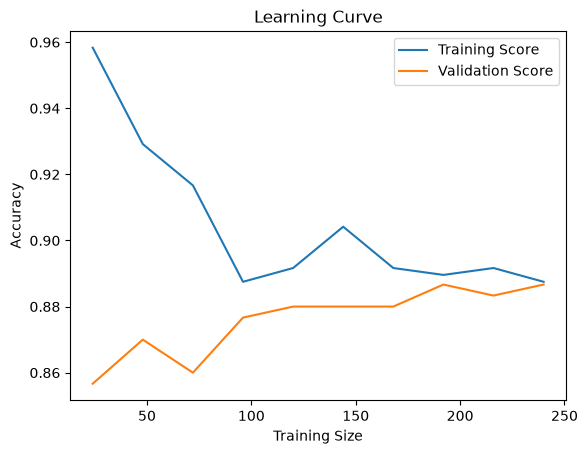

In [5]:
# LEARNING CURVES

from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# mean scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# plot
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()

## Underfitting

### What happens?

- training score low
- validation score low

### Interpretation

Model is too simple:

--> cannot capture pattern


### Causes

- too much regularization
- wrong model type
- insufficient features

### Fix

- increase model complexity
- add features
- reduce regularization

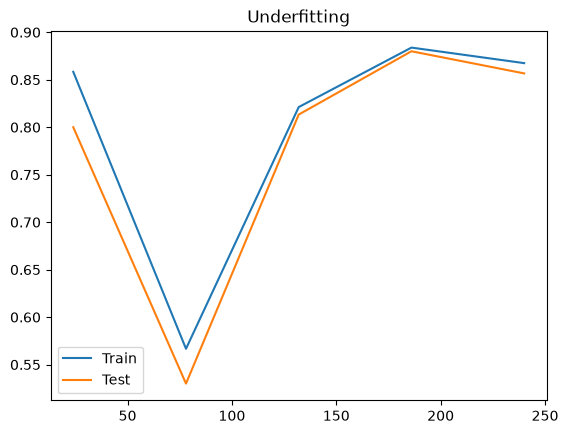

In [6]:
# UNDERFITTING EXAMPLE

from sklearn.linear_model import LogisticRegression

simple_model = LogisticRegression(C=0.001, max_iter=1000)

train_sizes, train_scores, test_scores = learning_curve(
    simple_model, X, y, cv=5
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Test")

plt.title("Underfitting")
plt.legend()
plt.show()

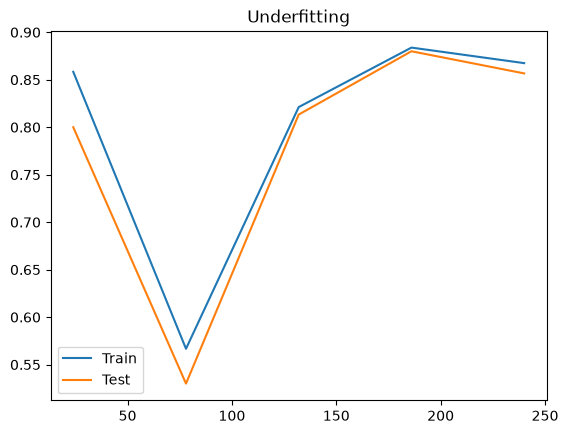

In [7]:
# UNDERFITTING EXAMPLE

from sklearn.linear_model import LogisticRegression

simple_model = LogisticRegression(C=0.001, max_iter=1000)

train_sizes, train_scores, test_scores = learning_curve(
    simple_model, X, y, cv=5
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Test")

plt.title("Underfitting")
plt.legend()
plt.show()

## Overfitting

### What happens?

- training score very high
- validation score lower

### Interpretation

Model memorizes data:

--> does NOT generalize

### Causes

- model too complex
- too many parameters
- too little data

### Fix

- increase regularization
- reduce complexity
- add more data

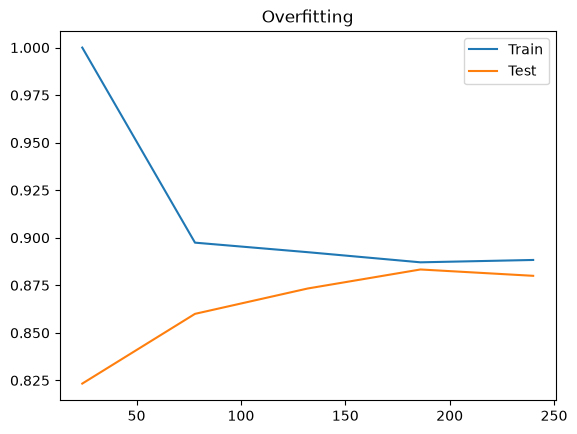

In [8]:
# OVERFITTING EXAMPLE
overfit_model = LogisticRegression(C=1000, max_iter=1000)

train_sizes, train_scores, test_scores = learning_curve(
    overfit_model, X, y, cv=5
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Test")

plt.title("Overfitting")
plt.legend()
plt.show()


## Good Fit

### What happens?

- training score high
- validation score also high
- small gap

### Interpretation

Model generalizes well

### Key Insight

Goal is NOT perfect training accuracy

Goal is:

    good generalization

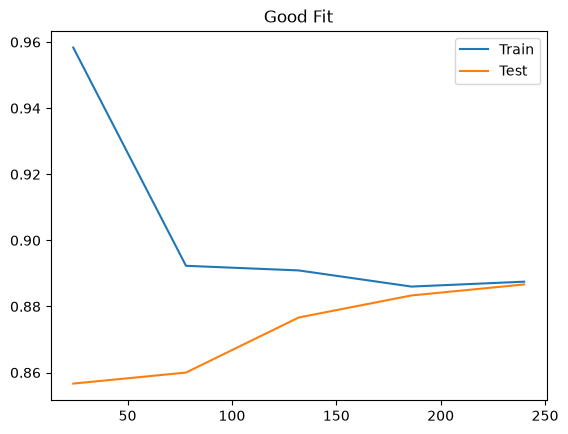

In [9]:
# WELL-FITTED MODEL

good_model = LogisticRegression(C=1.0, max_iter=1000)

train_sizes, train_scores, test_scores = learning_curve(
    good_model, X, y, cv=5
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Test")

plt.title("Good Fit")
plt.legend()
plt.show()

## Effect of Data Size

### Small dataset

- unstable results
- high variance

### More data

- stabilizes model
- improves generalization

### Key Insight

More data often beats better models

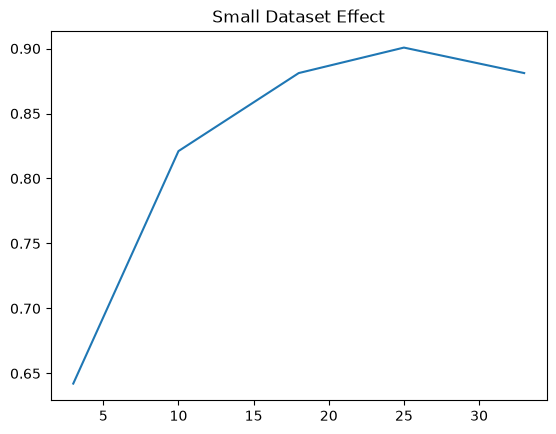

In [10]:
# EFFECT OF DATA

small_X = X[:50]
small_y = y[:50]

model = LogisticRegression(max_iter=1000)

train_sizes, train_scores, test_scores = learning_curve(
    model, small_X, small_y, cv=3
)

plt.plot(train_sizes, test_scores.mean(axis=1))
plt.title("Small Dataset Effect")
plt.show()

## Diagnose Your Model

### Case 1

Train low Test low

--> underfitting  
--> increase complexity  

### Case 2

Train high Test low

--> overfitting  
--> regularize / more data  

### Case 3

Train high Test high

--> good model  

### Key Insight

Learning curves are a diagnostic tool
